In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

class AdditiveAttention(layers.Layer):
    # Lớp này rà soát 250 ký tự chấm điểm xem ký tự nào quan trọng như ', UNION, -- rồi gom lại thành vector 64 chiều duy nhất 
    # chứa trọn vẹn điểm nhấn của câu lệnh 
    
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units #Số chiều trung gian ẩn của Attention
        self.supports_masking = True

    def build(self, input_shape): #Bộ 3 trọng số tự học
        feat_dim = input_shape[-1] #64
        self.W = self.add_weight(
            name="W", shape=(feat_dim, self.units),
            initializer="glorot_uniform", trainable=True
        )
        self.b = self.add_weight(
            name="b", shape=(self.units,),
            initializer="zeros", trainable=True
        )
        self.v = self.add_weight(
            name="v", shape=(self.units, 1),
            initializer="glorot_uniform", trainable=True
        )
        super().build(input_shape)

    def call(self, inputs, mask=None): #4 bước xử lí
        # inputs: (batch, timesteps, feat_dim) #ma trận chứa 250 trangnj thái ẩn từ LSTM
        #chấm điểm thô cho từng ký tự
        score = tf.tanh(tf.tensordot(inputs, self.W, axes=[[2], [0]]) + self.b)
        score = tf.tensordot(score, self.v, axes=[[2], [0]])  
        score = tf.squeeze(score, axis=-1)                     

        if mask is not None:
            mask = tf.cast(mask, dtype=score.dtype)
            score = score + (1.0 - mask) * -1e9

        #biến điểm thô thành tỷ lệ phần trăm chú ý
        alpha = tf.nn.softmax(score, axis=1)             
        alpha = tf.expand_dims(alpha, axis=-1)             
        context = tf.reduce_sum(inputs * alpha, axis=1)    

        return context, alpha

    def compute_mask(self, inputs, mask=None):
        return None

In [ ]:
np.random.seed(42)
BATCH, TIMESTEPS, UNITS = 4, 250, 64

fake_input = tf.constant(np.random.randn(BATCH, TIMESTEPS, UNITS), dtype=tf.float32)
attn = AdditiveAttention(units=64, name="additive_attention_test")

# Test 1-3: không mask
context, alpha = attn(fake_input)
print("context shape:", context.shape)   # kỳ vọng (4, 64)
print("alpha shape:", alpha.shape)       # kỳ vọng (4, 250, 1)

alpha_sum = tf.reduce_sum(alpha, axis=1).numpy().flatten()
print("Tổng alpha theo thời gian (không mask):", alpha_sum)
assert np.allclose(alpha_sum, 1.0, atol=1e-5), "FAIL: alpha không tổng bằng 1"
print("PASS: tổng alpha = 1 (không mask)\n")

# Test 4: có mask, mô phỏng padding cuối cây
mask = np.ones((BATCH, TIMESTEPS), dtype=bool)
mask[0, 150:] = False   # mẫu 0: 100 vị trí PAD ở cuối
mask[1, 200:] = False   # mẫu 1: 50 vị trí PAD ở cuối
mask_tf = tf.constant(mask)

context_m, alpha_m = attn(fake_input, mask=mask_tf)
alpha_m_sum = tf.reduce_sum(alpha_m, axis=1).numpy().flatten()
print("Tổng alpha theo thời gian (có mask):", alpha_m_sum)
assert np.allclose(alpha_m_sum, 1.0, atol=1e-5), "FAIL: alpha (có mask) không tổng bằng 1"
print("PASS: tổng alpha = 1 (có mask)\n")

alpha_m_np = alpha_m.numpy().squeeze(-1)
max_pad_alpha_0 = alpha_m_np[0, 150:].max()
max_pad_alpha_1 = alpha_m_np[1, 200:].max()
print("Alpha lớn nhất tại vị trí PAD (mẫu 0):", max_pad_alpha_0)
print("Alpha lớn nhất tại vị trí PAD (mẫu 1):", max_pad_alpha_1)
assert max_pad_alpha_0 < 1e-6, "FAIL: alpha tại PAD (mẫu 0) chưa gần 0"
assert max_pad_alpha_1 < 1e-6, "FAIL: alpha tại PAD (mẫu 1) chưa gần 0"
print("PASS: alpha tại vị trí PAD ~ 0\n")

# Kiểm tra so với công thức tính tay
n_params = attn.count_params()
expected = 64*64 + 64 + 64*1   # W + b + v = 4224
print("Số tham số Attention:", n_params, "| Kỳ vọng:", expected)
assert n_params == expected, "FAIL: số tham số không khớp công thức tay"
print("PASS: số tham số khớp công thức tay (W:64×64, b:64, v:64×1 = 4224)")

context shape: (4, 64)
alpha shape: (4, 250, 1)
Tổng alpha theo thời gian (không mask): [1. 1. 1. 1.]
PASS: tổng alpha = 1 (không mask)

Tổng alpha theo thời gian (có mask): [1. 1. 1. 1.]
PASS: tổng alpha = 1 (có mask)

Alpha lớn nhất tại vị trí PAD (mẫu 0): 0.0
Alpha lớn nhất tại vị trí PAD (mẫu 1): 0.0
PASS: alpha tại vị trí PAD ~ 0

Số tham số Attention: 4224 | Kỳ vọng: 4224
PASS: số tham số khớp công thức tay (W:64×64, b:64, v:64×1 = 4224)


In [3]:
from tensorflow.keras import Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

VOCAB_SIZE = 96
MAX_LEN = 250
EMBED_DIM = 64
LSTM_UNITS = 64
ATTN_UNITS = 64   # đã chốt ở Ngày 1

inputs = Input(shape=(MAX_LEN,), name="input_sequence")

x = layers.Embedding(
    input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
    mask_zero=True,           # đã chốt ở Ngày 1 — bắt buộc để lan mask qua LSTM/Attention
    name="embedding"
)(inputs)

lstm_out = layers.LSTM(
    LSTM_UNITS, return_sequences=True,   # khác Tầng 2 (False) — giữ toàn bộ hidden state
    name="lstm"
)(x)

context, alpha = AdditiveAttention(units=ATTN_UNITS, name="additive_attention")(lstm_out)

dropped = layers.Dropout(0.2, name="dropout")(context)
outputs = layers.Dense(1, activation="sigmoid", name="output")(dropped)

model = Model(inputs=inputs, outputs=outputs, name="tier3_lstm_attention")

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", Precision(name="precision"), Recall(name="recall")]
)

model.summary()

Model: "tier3_lstm_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 64)   │      6,144 │ input_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 250)       │          0 │ input_sequence[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 250, 64)   │     33,024 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additive_attention  │ [(None, 64),      │      4,224 │ lstm[0][0],       │
│ (AdditiveAttention) │ (None, 250, 1)]   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ additive_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,457 (169.75 KB)

 Trainable params: 43,457 (169.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
expected_embedding = VOCAB_SIZE * EMBED_DIM
expected_lstm = 4 * (EMBED_DIM * LSTM_UNITS + LSTM_UNITS * LSTM_UNITS + LSTM_UNITS)
expected_attention = ATTN_UNITS * ATTN_UNITS + ATTN_UNITS + ATTN_UNITS * 1
expected_dense = LSTM_UNITS * 1 + 1
expected_total = expected_embedding + expected_lstm + expected_attention + expected_dense

print("Kỳ vọng Embedding :", expected_embedding)   # 96*64 = 6144
print("Kỳ vọng LSTM       :", expected_lstm)        # 4*(64*64+64*64+64) = 33024
print("Kỳ vọng Attention  :", expected_attention)   # 64*64+64+64 = 4224
print("Kỳ vọng Dense      :", expected_dense)        # 64+1 = 65
print("Kỳ vọng Tổng       :", expected_total)        # 43457

print("Thực tế (model.count_params()):", model.count_params())
assert model.count_params() == expected_total, "FAIL: tổng tham số không khớp công thức tay"
print("PASS: tổng tham số khớp công thức tay")

Kỳ vọng Embedding : 6144
Kỳ vọng LSTM       : 33024
Kỳ vọng Attention  : 4224
Kỳ vọng Dense      : 65
Kỳ vọng Tổng       : 43457
Thực tế (model.count_params()): 43457
PASS: tổng tham số khớp công thức tay


In [ ]:
import json

with open("../artifacts/tier2_class_weight_decision.json", "r", encoding="utf-8") as f:
    cw_raw = json.load(f)

print(cw_raw)

{'used': True, 'method': 'sklearn.utils.class_weight.compute_class_weight(balanced)', 'values': {'0': 0.7913499239817556, '1': 1.3580747047514419}, 'decision_date': 'Tuần 5, Ngày 3-4', 'note': 'PHẢI dùng lại đúng giá trị/phương pháp này cho Tầng 3 (LSTM+Attention) ở Tuần 6 để đảm bảo so sánh công bằng ở Tuần 7.'}


In [ ]:
import numpy as np
import pandas as pd

# B1: Nạp ma trận sequence (X) từ các file .npy đã xử lý ở Tuần 5
X_train = np.load("../datasets/processed/train_split_sequences.npy")
X_val = np.load("../datasets/processed/val_split_sequences.npy")

# B2: Nạp nhãn (y) từ file csv
train_split_df = pd.read_csv("../datasets/processed/train_split.csv")
val_split_df = pd.read_csv("../datasets/processed/val_split.csv")

y_train = train_split_df["Label"].values
y_val = val_split_df["Label"].values

# B3: Kiểm tra kích thước trước khi fit
print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_val shape:  ", X_val.shape, "| y_val shape:  ", y_val.shape)

X_train shape: (19779, 250) | y_train shape: (19779,)
X_val shape:   (4945, 250) | y_val shape:   (4945,)


In [ ]:
import time
from tensorflow.keras.callbacks import Callback

class EpochTimer(Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()
    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._t0
        print(f"Epoch {epoch+1}: {elapsed:.1f}s | "
              f"loss={logs['loss']:.4f} val_loss={logs['val_loss']:.4f} "
              f"precision={logs['precision']:.4f} val_precision={logs['val_precision']:.4f} "
              f"recall={logs['recall']:.4f} val_recall={logs['val_recall']:.4f}")

class_weight = {
    0: cw_raw['values']['0'], 
    1: cw_raw['values']['1'], 
}
print(class_weight)  

history_probe = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[EpochTimer()],
    verbose=0 
)

{0: 0.7913499239817556, 1: 1.3580747047514419}
Epoch 1: 81.8s | loss=0.0924 val_loss=0.0320 precision=0.9145 val_precision=0.9978 recall=0.9802 val_recall=0.9841
Epoch 2: 83.8s | loss=0.0235 val_loss=0.0218 precision=0.9979 val_precision=0.9978 recall=0.9907 val_recall=0.9896
Epoch 3: 65.8s | loss=0.0324 val_loss=0.0406 precision=0.9874 val_precision=0.9809 recall=0.9923 val_recall=0.9885


In [ ]:
inputs = Input(shape=(MAX_LEN,), name="input_sequence")

x = layers.Embedding(
    input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
    mask_zero=True, name="embedding"
)(inputs)

lstm_out = layers.LSTM(LSTM_UNITS, return_sequences=True, name="lstm")(x)

context, alpha = AdditiveAttention(units=ATTN_UNITS, name="additive_attention")(lstm_out)

dropped = layers.Dropout(0.2, name="dropout")(context)
outputs = layers.Dense(1, activation="sigmoid", name="output")(dropped)

model = Model(inputs=inputs, outputs=outputs, name="tier3_lstm_attention")

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", Precision(name="precision"), Recall(name="recall")]
)

print("Model đã khởi tạo lại — trọng số mới, sẵn sàng huấn luyện chính thức.")
print("Tổng tham số:", model.count_params()) 

Model đã khởi tạo lại — trọng số mới, sẵn sàng huấn luyện chính thức.
Tổng tham số: 43457


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True   
)

start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,   # tái sử dụng từ đoạn code trên
    callbacks=[early_stop, EpochTimer()],
    verbose=0
)

total_time = time.time() - start_time
print(f"\nTổng thời gian huấn luyện: {total_time/60:.1f} phút")
print(f"Số epoch thực chạy: {len(history.history['loss'])}")

best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"Epoch có val_loss tốt nhất: {best_epoch} "
      f"(val_loss={min(history.history['val_loss']):.4f})")

Epoch 1: 106.6s | loss=0.0882 val_loss=0.0383 precision=0.9187 val_precision=0.9868 recall=0.9839 val_recall=0.9885
Epoch 2: 69.0s | loss=0.0354 val_loss=0.0243 precision=0.9949 val_precision=0.9972 recall=0.9879 val_recall=0.9874
Epoch 3: 86.5s | loss=0.0171 val_loss=0.0257 precision=0.9983 val_precision=0.9950 recall=0.9926 val_recall=0.9907
Epoch 4: 106.5s | loss=0.0135 val_loss=0.0188 precision=0.9990 val_precision=0.9972 recall=0.9940 val_recall=0.9907
Epoch 5: 107.2s | loss=0.0118 val_loss=0.0167 precision=0.9989 val_precision=0.9978 recall=0.9949 val_recall=0.9923
Epoch 6: 110.5s | loss=0.0170 val_loss=0.0172 precision=0.9979 val_precision=0.9978 recall=0.9934 val_recall=0.9923
Epoch 7: 109.6s | loss=0.0167 val_loss=0.1548 precision=0.9949 val_precision=0.9286 recall=0.9948 val_recall=0.9929
Epoch 8: 66.9s | loss=0.0328 val_loss=0.0532 precision=0.9798 val_precision=0.9741 recall=0.9942 val_recall=0.9923
Epoch 9: 68.0s | loss=0.0285 val_loss=0.0242 precision=0.9838 val_precision

In [12]:
history_dict = {
    "loss": history.history["loss"],
    "val_loss": history.history["val_loss"],
    "precision": history.history["precision"],
    "val_precision": history.history["val_precision"],
    "recall": history.history["recall"],
    "val_recall": history.history["val_recall"],
    "best_epoch": best_epoch,
    "total_epochs_run": len(history.history["loss"]),
    "total_training_time_seconds": total_time,
}

with open("../artifacts/tier3_training_history.json", "w", encoding="utf-8") as f:
    json.dump(history_dict, f, ensure_ascii=False, indent=2)

print("Đã lưu artifacts/tier3_training_history.json")

Đã lưu artifacts/tier3_training_history.json


In [13]:
model.save("../models/tier3_lstm_attention.h5")
print("Đã lưu models/tier3_lstm_attention.h5")

Đã lưu models/tier3_lstm_attention.h5


In [14]:
import matplotlib.pyplot as plt

with open("../artifacts/tier2_training_history.json", "r", encoding="utf-8") as f:
    tier2_hist = json.load(f)

print(list(tier2_hist.keys()))

['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall']


Tier 2 best epoch (tính lại, đối chiếu với 22 đã biết): 22
Tier 3 best epoch: 5


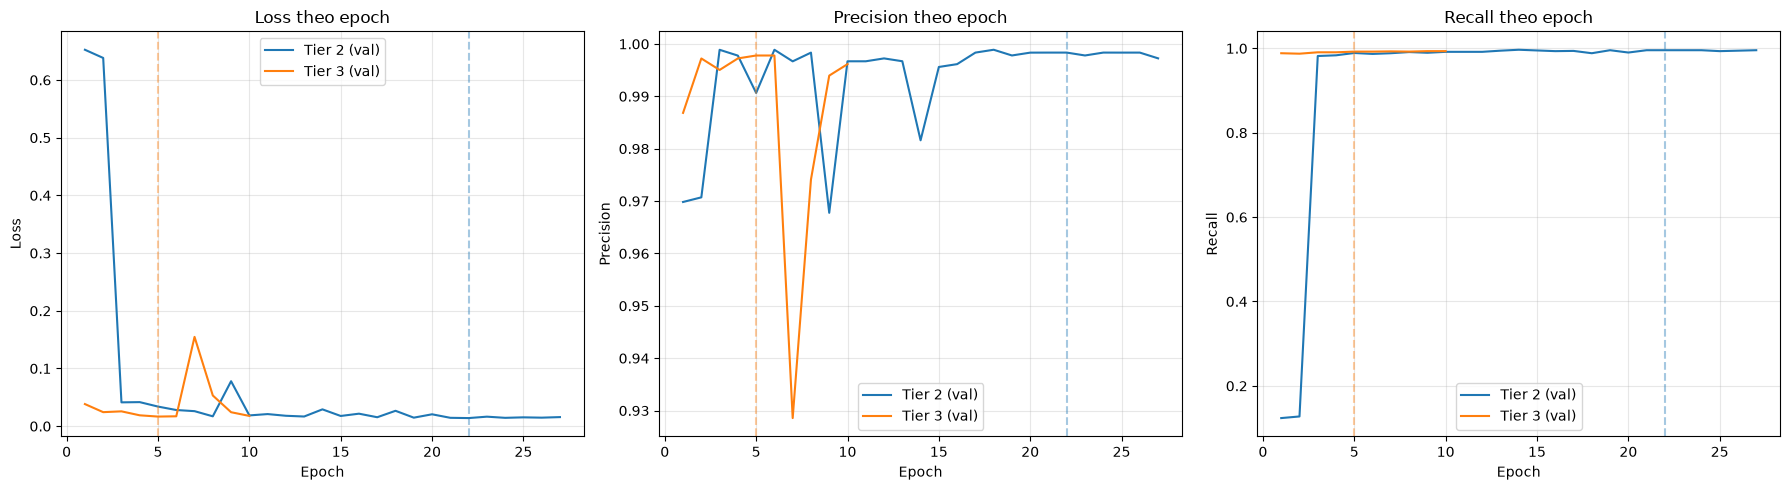

Đã lưu docs/Week06/tier2_vs_tier3_training_curves.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

tier2_best_epoch = int(np.argmin(tier2_hist["val_loss"])) + 1
tier3_best_epoch = history_dict["best_epoch"]

print("Tier 2 best epoch (tính lại, đối chiếu với 22 đã biết):", tier2_best_epoch)
print("Tier 3 best epoch:", tier3_best_epoch)
assert tier2_best_epoch == 22, "CẢNH BÁO: best epoch tính lại của Tầng 2 không khớp 22 đã ghi nhận trước đó"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ("loss", "val_loss", "Loss"),
    ("precision", "val_precision", "Precision"),
    ("recall", "val_recall", "Recall"),
]

for ax, (train_key, val_key, title) in zip(axes, metrics):
    epochs_t2 = range(1, len(tier2_hist[train_key]) + 1)
    epochs_t3 = range(1, len(history_dict[train_key]) + 1)

    ax.plot(epochs_t2, tier2_hist[val_key], label="Tier 2 (val)", color="tab:blue")
    ax.plot(epochs_t3, history_dict[val_key], label="Tier 3 (val)", color="tab:orange")

    ax.axvline(tier2_best_epoch, color="tab:blue", linestyle="--", alpha=0.4)
    ax.axvline(tier3_best_epoch, color="tab:orange", linestyle="--", alpha=0.4)

    ax.set_title(f"{title} theo epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/Week06/tier2_vs_tier3_training_curves.png", dpi=150)
plt.show()
print("Đã lưu docs/Week06/tier2_vs_tier3_training_curves.png")

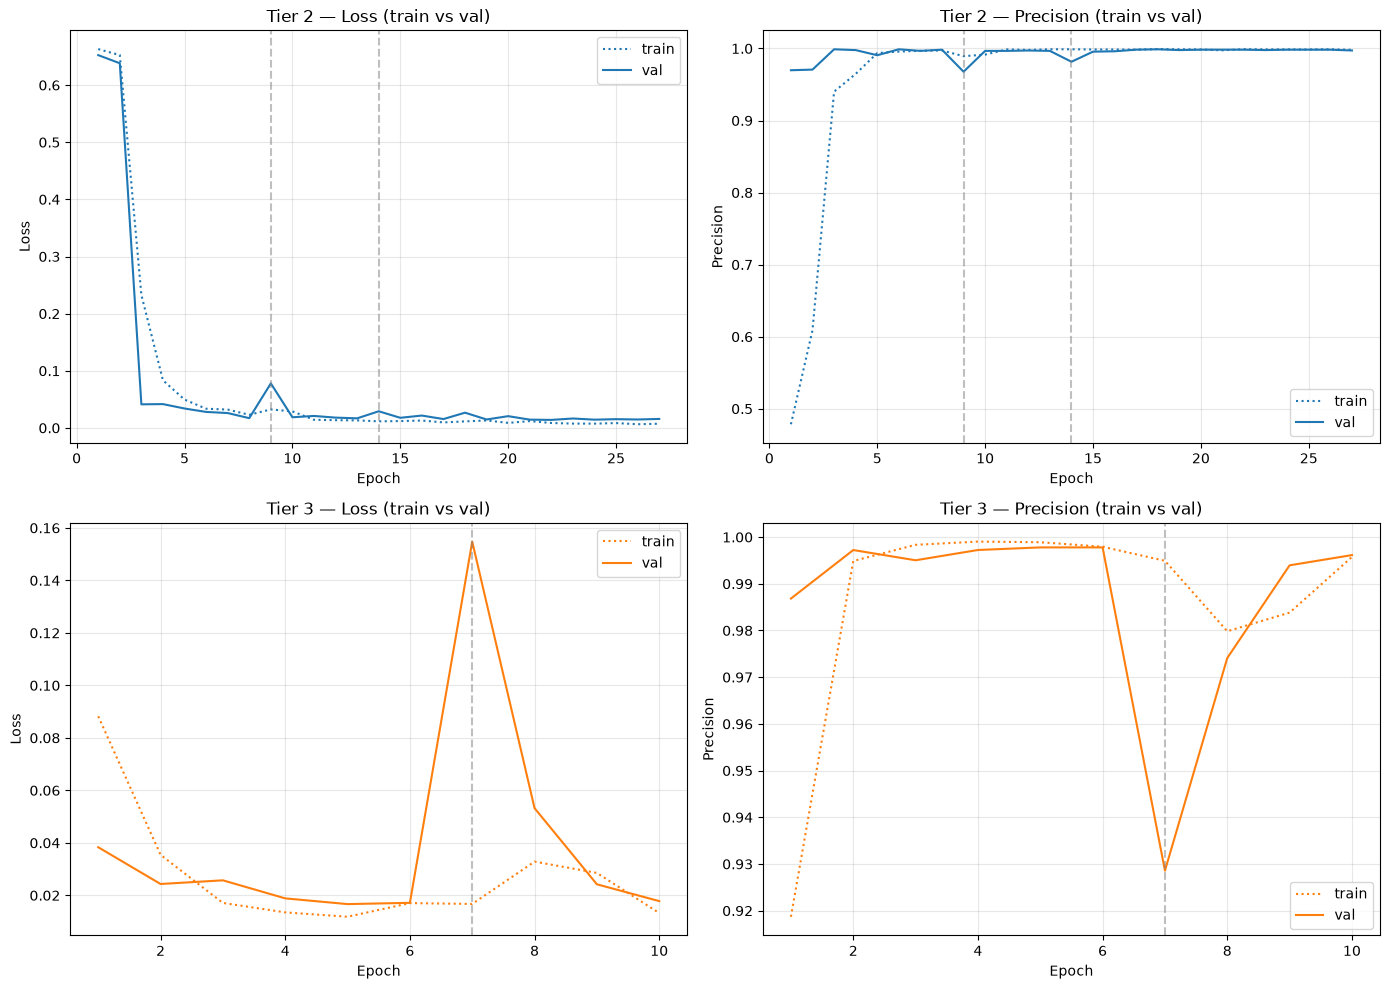

Đã lưu docs/Week06/tier2_tier3_train_vs_val_dip_analysis.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- Tier 2 — Loss ----
epochs_t2 = range(1, len(tier2_hist["loss"]) + 1)
axes[0,0].plot(epochs_t2, tier2_hist["loss"], label="train", linestyle=":", color="tab:blue")
axes[0,0].plot(epochs_t2, tier2_hist["val_loss"], label="val", color="tab:blue")
axes[0,0].axvline(9, color="gray", linestyle="--", alpha=0.5)
axes[0,0].axvline(14, color="gray", linestyle="--", alpha=0.5)
axes[0,0].set_title("Tier 2 — Loss (train vs val)")
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss")
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# ---- Tier 2 — Precision ----
axes[0,1].plot(epochs_t2, tier2_hist["precision"], label="train", linestyle=":", color="tab:blue")
axes[0,1].plot(epochs_t2, tier2_hist["val_precision"], label="val", color="tab:blue")
axes[0,1].axvline(9, color="gray", linestyle="--", alpha=0.5)
axes[0,1].axvline(14, color="gray", linestyle="--", alpha=0.5)
axes[0,1].set_title("Tier 2 — Precision (train vs val)")
axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("Precision")
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# ---- Tier 3 — Loss ----
epochs_t3 = range(1, len(history_dict["loss"]) + 1)
axes[1,0].plot(epochs_t3, history_dict["loss"], label="train", linestyle=":", color="tab:orange")
axes[1,0].plot(epochs_t3, history_dict["val_loss"], label="val", color="tab:orange")
axes[1,0].axvline(7, color="gray", linestyle="--", alpha=0.5)
axes[1,0].set_title("Tier 3 — Loss (train vs val)")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("Loss")
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# ---- Tier 3 — Precision ----
axes[1,1].plot(epochs_t3, history_dict["precision"], label="train", linestyle=":", color="tab:orange")
axes[1,1].plot(epochs_t3, history_dict["val_precision"], label="val", color="tab:orange")
axes[1,1].axvline(7, color="gray", linestyle="--", alpha=0.5)
axes[1,1].set_title("Tier 3 — Precision (train vs val)")
axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("Precision")
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/Week06/tier2_tier3_train_vs_val_dip_analysis.png", dpi=150)
plt.show()
print("Đã lưu docs/Week06/tier2_tier3_train_vs_val_dip_analysis.png")

In [17]:
import pandas as pd

test_df = pd.read_csv("../datasets/processed/test.csv")
print("Shape:", test_df.shape)          
print("Columns:", test_df.columns.tolist())
print(test_df.head(3))
print("\nPhân bố nhãn:")
print(test_df.iloc[:, -1].value_counts())   

Shape: (6181, 2)
Columns: ['Query', 'Label']
                                      Query  Label
0                                   hinojal      0
1  SELECT COUNT ( excellent )  FROM dropped      0
2                       pasaje cox 194, 5?f      0

Phân bố nhãn:
Label
0    3905
1    2276
Name: count, dtype: int64


In [19]:
import numpy as np
import pandas as pd

test_sequences = np.load("../datasets/processed/test_sequences.npy")

test_df = pd.read_csv("../datasets/processed/test.csv")
print(
    "test_sequences shape:",
    test_sequences.shape,
) 
print("test_df shape:       ", test_df.shape)  

test_sequences shape: (6181, 250)
test_df shape:        (6181, 2)


In [ ]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

y_test = test_df["Label"].values
print("y_test shape:", y_test.shape)  
assert y_test.shape[0] == test_sequences.shape[0], \
print("PASS: số hàng khớp test_sequences.npy — an toàn để trích nhãn theo thứ tự gốc")

y_pred_proba = model.predict(test_sequences, batch_size=64, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")
print(f"F1-score:  {f1:.6f}")
print("\nConfusion Matrix:")
print(f"           Pred 0   Pred 1")
print(f"Actual 0   {cm[0,0]:<8} {cm[0,1]:<8}")
print(f"Actual 1   {cm[1,0]:<8} {cm[1,1]:<8}")

print("\n" + classification_report(y_test, y_pred, target_names=["Legitimate", "SQLi"]))

y_test shape: (6181,)
PASS: số hàng khớp test_sequences.npy — an toàn để trích nhãn theo thứ tự gốc
Precision: 0.998671
Recall:    0.990773
F1-score:  0.994707

Confusion Matrix:
           Pred 0   Pred 1
Actual 0   3902     3       
Actual 1   21       2255    

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00      3905
        SQLi       1.00      0.99      0.99      2276

    accuracy                           1.00      6181
   macro avg       1.00      1.00      1.00      6181
weighted avg       1.00      1.00      1.00      6181



In [21]:
comparison = {
    "Tier 1 - Random Forest": {"precision": None, "recall": None, "f1": 0.995818},
    "Tier 1 - SVM":           {"precision": None, "recall": None, "f1": 0.993826},
    "Tier 2 - LSTM baseline": {"precision": 0.9987, "recall": 0.9930, "f1": 0.995814},
    "Tier 3 - LSTM+Attention": {"precision": round(precision, 6), "recall": round(recall, 6), "f1": round(f1, 6)},
}

print(f"{'Model':<26} {'Precision':<12} {'Recall':<12} {'F1-score':<12}")
for name, m in comparison.items():
    p = f"{m['precision']:.4f}" if m["precision"] is not None else "—"
    r = f"{m['recall']:.4f}" if m["recall"] is not None else "—"
    print(f"{name:<26} {p:<12} {r:<12} {m['f1']:.6f}")

# Lưu kết quả Tầng 3 riêng (dùng artifact chuẩn hóa cho Tuần 7 tổng hợp)
tier3_test_results = {
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "confusion_matrix": cm.tolist(),
    "threshold": 0.5,
    "model_checkpoint": "best_weights_restored_epoch_5",
    "note": "Đánh giá trên test.csv, dùng chung tập test với Tầng 1 và Tầng 2, không random lại."
}

with open("artifacts/tier3_test_results.json", "w", encoding="utf-8") as f:
    json.dump(tier3_test_results, f, ensure_ascii=False, indent=2)

print("\nĐã lưu artifacts/tier3_test_results.json")

Model                      Precision    Recall       F1-score    
Tier 1 - Random Forest     —            —            0.995818
Tier 1 - SVM               —            —            0.993826
Tier 2 - LSTM baseline     0.9987       0.9930       0.995814
Tier 3 - LSTM+Attention    0.9987       0.9908       0.994707

Đã lưu artifacts/tier3_test_results.json


In [22]:
with open("../artifacts/vocab.json", "r", encoding="utf-8") as f:
    vocab = json.load(f)

print("Kiểu dữ liệu:", type(vocab))
print("Số phần tử:", len(vocab))
if isinstance(vocab, dict):
    print("10 phần tử đầu:", dict(list(vocab.items())[:10]))
else:
    print("10 phần tử đầu:", vocab[:10])

Kiểu dữ liệu: <class 'dict'>
Số phần tử: 96
10 phần tử đầu: {'<PAD>': 0, '<UNK>': 1, ' ': 2, '!': 3, '"': 4, '#': 5, '$': 6, '%': 7, '&': 8, "'": 9}


In [ ]:
attention_layer = model.get_layer("additive_attention")
alpha_output = attention_layer.output[1]  
attention_extractor = Model(
    inputs=model.input,
    outputs=alpha_output,
    name="tier3_attention_extractor"
)
print("Output shape của attention_extractor:", attention_extractor.output_shape)

Output shape của attention_extractor: (None, 250, 1)


In [ ]:
id_to_char = {v: k for k, v in vocab.items()}

def decode_sequence(seq_ids):
    return ''.join(id_to_char.get(int(i), '?') for i in seq_ids)

y_pred_proba_flat = y_pred_proba.flatten()   

tn_mask = (y_test == 0) & (y_pred == 0)
tp_mask = (y_test == 1) & (y_pred == 1)
fn_mask = (y_test == 1) & (y_pred == 0)

tn_idx = np.where(tn_mask)[0]
tp_idx = np.where(tp_mask)[0]
fn_idx = np.where(fn_mask)[0]

print("Số mẫu mỗi loại — TN:", len(tn_idx), "| TP:", len(tp_idx), "| FN:", len(fn_idx))
assert len(fn_idx) == 21

selected_tn = tn_idx[np.argsort(y_pred_proba_flat[tn_idx])][:3]     
selected_tp = tp_idx[np.argsort(-y_pred_proba_flat[tp_idx])][:3]   
selected_fn = fn_idx                                                  

selected_all = np.concatenate([selected_tn, selected_tp, selected_fn])
print("Tổng số mẫu được chọn:", len(selected_all))
assert len(selected_all) == 27
print("PASS: đủ 27 mẫu (3 TN + 3 TP + 21 FN)")

Số mẫu mỗi loại — TN: 3902 | TP: 2255 | FN: 21
Tổng số mẫu được chọn: 27
PASS: đủ 27 mẫu (3 TN + 3 TP + 21 FN)


In [ ]:
alpha_all = attention_extractor.predict(test_sequences[selected_all], batch_size=64, verbose=0)
# alpha_all shape: (27, 250, 1)

samples_data = []
for rank, idx in enumerate(selected_all):
    if idx in selected_tn:
        category = "TN_confident"
    elif idx in selected_tp:
        category = "TP_confident"
    else:
        category = "FN_missed"

    seq_ids = test_sequences[idx]
    decoded = decode_sequence(seq_ids)
    alpha_seq = alpha_all[rank].flatten().tolist()   # 250 giá trị alpha

    samples_data.append({
        "test_index": int(idx),
        "category": category,
        "original_query": test_df.iloc[idx]["Query"],
        "true_label": int(y_test[idx]),
        "predicted_label": int(y_pred[idx]),
        "predicted_probability": float(y_pred_proba_flat[idx]),
        "decoded_sequence": decoded,          
        "token_ids": seq_ids.tolist(),
        "alpha_weights": alpha_seq,          
    })

output = {
    "extraction_method": "Phương án A - model phụ Functional API, dùng chung trọng số đã học",
    "model_checkpoint": "best_weights_restored_epoch_5",
    "total_samples": len(samples_data),
    "breakdown": {"TN_confident": 3, "TP_confident": 3, "FN_missed": 21},
    "note": "Toàn bộ 21 mẫu FN_missed là các SQLi thật bị Tầng 3 bỏ sót (so với Tầng 2 chỉ bỏ sót 16) — dữ liệu chính cho phân tích nguyên nhân ở Tuần 7.",
    "samples": samples_data,
}

with open("../artifacts/tier3_attention_weights_samples.json", "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"Đã lưu artifacts/tier3_attention_weights_samples.json — {len(samples_data)} mẫu")


sample0 = samples_data[3]   
print("\nVí dụ 1 mẫu FN:")
print("Query gốc:", sample0["original_query"])
print("Xác suất dự đoán:", sample0["predicted_probability"])
print("3 vị trí có alpha lớn nhất:",
      sorted(range(250), key=lambda i: -sample0["alpha_weights"][i])[:3])

Đã lưu artifacts/tier3_attention_weights_samples.json — 27 mẫu

Ví dụ 1 mẫu FN:
Query gốc: -2032%"   )    )     )   or   (  3082  =  7155  )  *7155 and    (    (     (  "%"  =  "
Xác suất dự đoán: 0.9999576807022095
3 vị trí có alpha lớn nhất: [79, 80, 86]


In [ ]:
sample_fn0 = samples_data[6]   
print("Category:", sample_fn0["category"])   
assert sample_fn0["category"] == "FN_missed", "FAIL: vẫn sai vị trí, kiểm tra lại thứ tự concatenate"

print("\nVí dụ 1 mẫu FN thật:")
print("Query gốc:", sample_fn0["original_query"])
print("Xác suất dự đoán:", sample_fn0["predicted_probability"])  
print("3 vị trí có alpha lớn nhất:",
      sorted(range(250), key=lambda i: -sample_fn0["alpha_weights"][i])[:3])

Category: FN_missed

Ví dụ 1 mẫu FN thật:
Query gốc: 1;SELECT *
Xác suất dự đoán: 0.026555601507425308
3 vị trí có alpha lớn nhất: [1, 0, 9]
